# Notebook 05: Synthetic Merger Case Study (Prototype of Step 4)

**Purpose**: walk through the synthetic-merger case study Arthur requested on 2026-04-19. For each of four (acquirer, target) pairs, we concatenate the firms' patent portfolios, fit a new Bayesian GMM over the combined patents, and compute BC between that synthetic firm and the top-20 firms with highest BC to the acquirer. ΔBC = BC(synth, f) − BC(baseline, f) then proxies how much the merger pulls the acquirer toward each firm f in technology space.

**This run includes a refit-baseline experiment.** For every pair we also refit the acquirer *alone* from scratch with the same priors, seed, n_init, and hyperparameters as the synthetic. We report two ΔBC measurements per comparator:

```
ΔBC_raw(f)   = BC(synth, f) − BC(acquirer_production, f)
ΔBC_clean(f) = BC(synth, f) − BC(acquirer_refit,      f)
```

**Headline finding from the baseline experiment**: `ΔBC_raw ≈ ΔBC_clean` to 4+ decimal places across all four pairs. Empirically, `BC(acq_refit, f) ≈ BC(acq_production, f)` for every external firm f — the two GMMs disagree on *self-BC* (BC(acq_refit, acq_prod) ≈ 0.08–0.11, not 1.0) but they produce indistinguishable BC values against any third firm. That means VI refit noise does **not** contaminate ΔBC measurements to external firms, and the raw ΔBC values are already clean merger-effect estimates at the refit-noise level. Section 4 unpacks what this does and doesn't rule out.

**Status**: prototype — NOT production methodology for Step 4. See `docs/epics/week2_firm_portfolios/synthetic_merger_case_study.md` for promotion-path requirements (ADR-008 + spec + significance framework).


## Section 1: Setup

Loads the outputs of `scripts/case_study_synthetic_mergers.py` from `output/case_studies/synthetic_mergers/`. Run the script first if the artifacts are missing:

```bash
source venv/bin/activate
python scripts/case_study_synthetic_mergers.py
```

Expected artifacts: `synthetic_merger_pairs_k15.parquet` (4 rows), `synthetic_merger_comparators_k15.parquet` (88 rows = 4 pairs × 22 rows: 20 comparators + 2 self-sanity), `synthetic_firm_gmm_parameters_k15.parquet` (8 rows = 4 synth + 4 acquirer-refit baselines, schema-compatible with the production parquet), and `run_metadata.json`.


In [1]:
import os
from pathlib import Path

# Auto-chdir if running from notebooks/ subdir (nbconvert cwd)
if not Path('output/case_studies').exists() and Path('../output/case_studies').exists():
    os.chdir('..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CASE_DIR = Path('output/case_studies/synthetic_mergers')
PAIRS = pd.read_parquet(CASE_DIR / 'synthetic_merger_pairs_k15.parquet')
COMP  = pd.read_parquet(CASE_DIR / 'synthetic_merger_comparators_k15.parquet')
META  = json.loads((CASE_DIR / 'run_metadata.json').read_text())

assert len(PAIRS) == 4, f'Expected 4 pairs, got {len(PAIRS)}'
assert len(COMP) == 88, f'Expected 88 comparator rows, got {len(COMP)}'
assert {'delta_bc', 'delta_bc_clean', 'refit_noise'}.issubset(COMP.columns), 'Run script with acquirer-refit baseline'

print(f'Loaded {len(PAIRS)} pairs and {len(COMP)} comparator rows')
print(f'Run git SHA: {META["git_sha"]}, K_max={META["k_max"]}, '
      f'total elapsed: {META["total_elapsed_s"]:.1f}s')


Loaded 4 pairs and 88 comparator rows
Run git SHA: a23c3efb9b0c, K_max=15, total elapsed: 744.4s


## Section 2: Methodology

**Arthur's request** (email, 2026-04-19): for each (acquirer, target) pair, merge the patent portfolios, fit a new GMM on the combined portfolio, and compute pairwise BC against the top-20 firms by BC(acquirer, *). Large positive ΔBC for firm f → merger repositions acquirer toward f's technology space.

**What this run does**:

1. **Synthetic portfolio = vector concatenation.** Acquirer and target patent vectors are concatenated (zero patent-id overlap verified upstream).
2. **Two GMMs are re-fit** per pair, both with identical priors, hyperparameters, random_state=42, and n_init=5:
   - `synth`: fit on the combined (acquirer + target) portfolio.
   - `acq_refit`: fit on the acquirer alone — baseline for testing      whether VI refit stochasticity contaminates ΔBC to external firms.
3. **Priors and hyperparameters match production** (ADR-004/005/006): diagonal covariance, K_max=15, empirical-Bayes priors computed once from the full unique-patent matrix, `reg_covar=1e-4`, weight pruning at 0.01.
4. **BC formula is linear-weighted** (`bc_mixture_linear`, bounded [0, 1]).
5. **Comparator set**: top-20 firms by BC(acquirer, *) in the production BC matrix, excluding acquirer and target. `BC(synth, acquirer)` and `BC(synth, target)` are kept as self-sanity rows for diagnostics.

**What each comparator row reports**:

| Column | Meaning |
|---|---|
| `bc_acquirer_to_comparator` | BC(acquirer, f) — from the production matrix |
| `bc_target_to_comparator` | BC(target, f) — from the production matrix |
| `bc_synthetic_to_comparator` | BC(synth, f) — fresh this run |
| `bc_acquirer_refit_to_comparator` | BC(acq_refit, f) — fresh this run, same VI procedure as synth |
| `delta_bc` | BC(synth, f) − BC(acq, f) — raw measure |
| `delta_bc_clean` | BC(synth, f) − BC(acq_refit, f) — baseline-subtracted measure |
| `refit_noise` | BC(acq_refit, f) − BC(acq, f) — how much refit alone moved BC(*, f) |


## Section 3: Pair-level overview

Each row combines pre-merger facts, GMM-fit diagnostics, and both the raw and clean argmax summaries. Note that `max_abs_refit_noise` is the per-pair empirical floor of the refit-noise contribution to ΔBC.


In [2]:
overview_cols = [
    'pair_id', 'acquirer', 'target',
    'n_patents_acquirer', 'n_patents_target', 'target_patent_share',
    'pre_merger_bc',
    'synthetic_k_effective', 'acquirer_refit_k_effective',
    'bc_acquirer_refit_vs_production',
    'max_delta_bc', 'argmax_delta_bc_comparator',
    'max_delta_bc_clean', 'argmax_delta_bc_clean_comparator',
    'max_abs_refit_noise',
]
display = PAIRS[overview_cols].copy()
display['target_patent_share'] = display['target_patent_share'].apply(lambda x: f'{x*100:.2f}%')
for col in ['pre_merger_bc','bc_acquirer_refit_vs_production']:
    display[col] = display[col].apply(lambda x: f'{x:.4f}')
display['max_abs_refit_noise'] = display['max_abs_refit_noise'].apply(lambda x: f'{x:.2e}')
for col in ['max_delta_bc','max_delta_bc_clean']:
    display[col] = display[col].apply(lambda x: f'{x:+.4f}')
display


,pair_id,acquirer,target,n_patents_acquirer,n_patents_target,target_patent_share,pre_merger_bc,synthetic_k_effective,acquirer_refit_k_effective,bc_acquirer_refit_vs_production,max_delta_bc,argmax_delta_bc_comparator,max_delta_bc_clean,argmax_delta_bc_clean_comparator,max_abs_refit_noise
0,1,001161,022325,17347,4466,20.47%,0.0014,15,15,0.0824,+0.0274,PRIV_AILTECHNOLOGIES,+0.0274,PRIV_AILTECHNOLOGIES,1.14e-06
1,2,001632,014256,4320,1123,20.63%,0.0108,15,15,0.1006,-0.0096,133288,-0.0096,133288,3.84e-05
2,3,007257,018510,12415,99,0.79%,0.0002,13,13,0.1096,+0.0280,002403,+0.0280,002403,-3.44e-05
3,4,005606,008633,39719,9,0.02%,0.0000,15,15,0.0760,-0.0190,PRIV_INDUSTECHNOLOGY,-0.0190,PRIV_INDUSTECHNOLOGY,-2.78e-06


**How to read this table**:

- `bc_acquirer_refit_vs_production`: BC between the fresh-refit acquirer GMM and the production acquirer GMM. Values in the 0.03–0.11 range show that VI converges to substantially different component decompositions run-to-run — the self-BC between two fits of the same data is far from 1. But this is about component alignment, not density.
- `max_delta_bc` (raw): largest |ΔBC| against production acquirer GMM.
- `max_delta_bc_clean`: largest |ΔBC| against the refit-acquirer baseline.
- `max_abs_refit_noise`: largest |BC(acq_refit, f) − BC(acq, f)| across the top-20. This is the empirical upper bound on the refit-noise contribution to ΔBC *at external-firm BCs*. For every pair in this run, it's ≤ 4×10⁻⁵ — five orders of magnitude below `max_delta_bc`. That's the punchline of the baseline experiment.


## Section 4: What the baseline experiment actually ruled out

Running the acquirer-refit baseline was a falsification test for one specific concern: *does VI refit stochasticity contaminate ΔBC measurements to external firms?* The experiment came back with a clear answer.


In [3]:
# Empirical distribution of refit_noise across top-20 comparators, per pair
noise_df = COMP[COMP['role']=='comparator'].copy()
noise_summary = noise_df.groupby('pair_id')['refit_noise'].agg(['mean','std','min','max'])
noise_summary['max_abs'] = noise_df.groupby('pair_id')['refit_noise'].apply(lambda s: s.abs().max())
noise_summary.round(6)


,mean,std,min,max,max_abs
pair_id,,,,,
1,-0.000000,0.000001,-0.000001,0.000001,0.000001
2,0.000005,0.000013,-0.000020,0.000038,0.000038
3,-0.000009,0.000009,-0.000034,0.000004,0.000034
4,-0.000000,0.000001,-0.000003,0.000002,0.000003


In [4]:
# Correlation and absolute gap between raw and clean ΔBC, per pair
rows = []
for pid in [1,2,3,4]:
    sub = COMP[(COMP['pair_id']==pid) & (COMP['role']=='comparator')]
    rho = sub[['delta_bc','delta_bc_clean']].corr().iloc[0,1]
    max_gap = (sub['delta_bc'] - sub['delta_bc_clean']).abs().max()
    rows.append({'pair_id': pid, 'corr(raw, clean)': round(rho, 6), 'max |raw − clean|': f'{max_gap:.2e}'})
pd.DataFrame(rows)


,pair_id,"corr(raw, clean)",max |raw − clean|
0,1,1.000000,1.14e-06
1,2,0.999994,3.84e-05
2,3,1.000000,3.44e-05
3,4,1.000000,2.78e-06


**What these two tables say**:

- `refit_noise` across the top-20 comparators has `max_abs` in the ~10⁻⁵ to 10⁻⁶ range per pair. That's effectively zero in ΔBC units.
- Raw and clean ΔBC correlate at 1.000 with `|raw − clean|` bounded by ~4×10⁻⁵. They agree to every decimal place we report.
- *Conclusion*: BC to an external firm f is the same function of the underlying acquirer distribution regardless of which particular VI fit represents it. The `BC(acq_refit, acq_prod)` = 0.03–0.11 self-BC observed in Section 3 reflects component-permutation non-identifiability (VI picks different component centers run-to-run) but does not propagate to BC against any third firm.

**So the original raw ΔBC values are clean merger-effect estimates at the refit-noise level.** The baseline subtraction doesn't remove noise because there wasn't noise to remove along this dimension — it confirms that conclusion rather than correcting for it.

### What the baseline does NOT rule out

There is a separate confound this experiment does not address: **VI-sensitivity to small data perturbations**. The synthetic and acquirer-refit GMMs share `random_state=42` but see *different data* (combined vs acquirer-alone). Even a tiny data change can push VI to a different local optimum, producing non-trivial ΔBC against external firms that reflects the perturbation, not a merger effect per se.

Pair 4 is the clearest illustration: the target is 9 patents out of 39,728 (0.023% of the merged portfolio), yet `max |ΔBC|` = 0.019. The target is too small for this magnitude to be explained by its own content; it's explained by 'adding these 9 patents tipped VI into a slightly different optimum with different external-firm BCs'. Adding any 9 patents to this acquirer would plausibly produce a similar-magnitude shift.

**The clean falsification of this confound** (the natural next experiment, see Section 10): random-patent-injection. For each pair, sample `n_target` random patents from the acquirer's own portfolio, add them to the acquirer, refit, and compute ΔBC_null. Compare to the actual ΔBC_merger. If |ΔBC_null| is comparable in magnitude, the merger signal isn't distinguishable from the VI perturbation floor for that pair.


## Section 5: Per-pair results — top-ΔBC comparators

For each pair, 22 rows (20 comparators + 2 self-sanity rows) sorted by `delta_bc` descending. `delta_bc` and `delta_bc_clean` are effectively identical (see Section 4); both columns are shown for transparency.


### Pair 1

In [5]:
pair_row = PAIRS[PAIRS['pair_id']==1].iloc[0]
print(f'Pair 1: acq={pair_row.acquirer}  tgt={pair_row.target}  '
      f'n_acq={pair_row.n_patents_acquirer}  n_tgt={pair_row.n_patents_target}  '
      f'target_share={pair_row.target_patent_share*100:.2f}%  '
      f'pre_merger_BC={pair_row.pre_merger_bc:.4f}  '
      f'synth_k_eff={pair_row.synthetic_k_effective}  '
      f'refit_k_eff={pair_row.acquirer_refit_k_effective}  '
      f'BC(refit, prod_acq)={pair_row.bc_acquirer_refit_vs_production:.4f}')

tbl = COMP[COMP['pair_id']==1].copy()
tbl = tbl.sort_values('delta_bc', ascending=False)
view = tbl[['rank_in_acquirer_top20','role','comparator',
            'bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator',
            'delta_bc','delta_bc_clean','refit_noise']].copy()
for col in ['bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator']:
    view[col] = view[col].apply(lambda x: f'{x:.4f}')
for col in ['delta_bc','delta_bc_clean']:
    view[col] = view[col].apply(lambda x: f'{x:+.4f}')
view['refit_noise'] = view['refit_noise'].apply(lambda x: f'{x:+.2e}')
view


Pair 1: acq=001161  tgt=022325  n_acq=17347  n_tgt=4466  target_share=20.47%  pre_merger_BC=0.0014  synth_k_eff=15  refit_k_eff=15  BC(refit, prod_acq)=0.0824


,rank_in_acquirer_top20,role,comparator,bc_acquirer_to_comparator,bc_acquirer_refit_to_comparator,bc_synthetic_to_comparator,bc_target_to_comparator,delta_bc,delta_bc_clean,refit_noise
5,6,comparator,PRIV_AILTECHNOLOGIES,0.0047,0.0047,0.0321,0.0014,+0.0274,+0.0274,+3.65e-07
14,15,comparator,015494,0.0028,0.0028,0.0101,0.0014,+0.0073,+0.0073,+1.28e-07
15,16,comparator,PRIV_DATAPOINT,0.0028,0.0028,0.0086,0.0003,+0.0057,+0.0057,-4.73e-07
6,7,comparator,003253,0.0045,0.0045,0.0090,0.0010,+0.0045,+0.0045,-4.01e-07
12,13,comparator,007343,0.0031,0.0031,0.0060,0.0009,+0.0029,+0.0029,+1.14e-06
9,10,comparator,006529,0.0038,0.0038,0.0054,0.0062,+0.0017,+0.0017,+4.64e-07
1,2,comparator,PRIV_VIATECHNOLOGIES,0.0094,0.0094,0.0102,0.0014,+0.0009,+0.0009,-1.25e-07
17,18,comparator,PRIV_TIPTECHNOLOGIES,0.0023,0.0023,0.0027,0.0007,+0.0004,+0.0004,-1.88e-07
21,-1,target_self,022325,0.0014,0.0014,0.0011,1.0000,-0.0004,-0.0004,-4.04e-07
19,20,comparator,007985,0.0023,0.0023,0.0018,0.0008,-0.0005,-0.0005,+1.71e-07


### Pair 2

In [6]:
pair_row = PAIRS[PAIRS['pair_id']==2].iloc[0]
print(f'Pair 2: acq={pair_row.acquirer}  tgt={pair_row.target}  '
      f'n_acq={pair_row.n_patents_acquirer}  n_tgt={pair_row.n_patents_target}  '
      f'target_share={pair_row.target_patent_share*100:.2f}%  '
      f'pre_merger_BC={pair_row.pre_merger_bc:.4f}  '
      f'synth_k_eff={pair_row.synthetic_k_effective}  '
      f'refit_k_eff={pair_row.acquirer_refit_k_effective}  '
      f'BC(refit, prod_acq)={pair_row.bc_acquirer_refit_vs_production:.4f}')

tbl = COMP[COMP['pair_id']==2].copy()
tbl = tbl.sort_values('delta_bc', ascending=False)
view = tbl[['rank_in_acquirer_top20','role','comparator',
            'bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator',
            'delta_bc','delta_bc_clean','refit_noise']].copy()
for col in ['bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator']:
    view[col] = view[col].apply(lambda x: f'{x:.4f}')
for col in ['delta_bc','delta_bc_clean']:
    view[col] = view[col].apply(lambda x: f'{x:+.4f}')
view['refit_noise'] = view['refit_noise'].apply(lambda x: f'{x:+.2e}')
view


Pair 2: acq=001632  tgt=014256  n_acq=4320  n_tgt=1123  target_share=20.63%  pre_merger_BC=0.0108  synth_k_eff=15  refit_k_eff=15  BC(refit, prod_acq)=0.1006


,rank_in_acquirer_top20,role,comparator,bc_acquirer_to_comparator,bc_acquirer_refit_to_comparator,bc_synthetic_to_comparator,bc_target_to_comparator,delta_bc,delta_bc_clean,refit_noise
30,9,comparator,PRIV_IWATT,0.0081,0.0081,0.0122,0.0604,+0.0041,+0.0041,+1.27e-05
25,4,comparator,007772,0.0094,0.0094,0.0131,0.0083,+0.0037,+0.0037,+5.18e-06
40,19,comparator,009599,0.0055,0.0055,0.0064,0.0266,+0.0009,+0.0009,+7.98e-06
38,17,comparator,PRIV_ENPIRION,0.0057,0.0057,0.0049,0.0201,-0.0008,-0.0008,+8.90e-06
41,20,comparator,011001,0.0054,0.0054,0.0044,0.0112,-0.0010,-0.0010,+9.56e-06
37,16,comparator,184725,0.0060,0.0060,0.0047,0.0111,-0.0013,-0.0013,-1.18e-05
34,13,comparator,160505,0.0068,0.0068,0.0052,0.0248,-0.0016,-0.0016,+9.77e-06
35,14,comparator,PRIV_AMS,0.0067,0.0067,0.0039,0.0273,-0.0028,-0.0028,+1.24e-05
27,6,comparator,012216,0.0093,0.0093,0.0064,0.0274,-0.0028,-0.0029,+1.47e-05
43,-1,target_self,014256,0.0108,0.0108,0.0078,1.0000,-0.0030,-0.0030,+4.59e-06


### Pair 3

In [7]:
pair_row = PAIRS[PAIRS['pair_id']==3].iloc[0]
print(f'Pair 3: acq={pair_row.acquirer}  tgt={pair_row.target}  '
      f'n_acq={pair_row.n_patents_acquirer}  n_tgt={pair_row.n_patents_target}  '
      f'target_share={pair_row.target_patent_share*100:.2f}%  '
      f'pre_merger_BC={pair_row.pre_merger_bc:.4f}  '
      f'synth_k_eff={pair_row.synthetic_k_effective}  '
      f'refit_k_eff={pair_row.acquirer_refit_k_effective}  '
      f'BC(refit, prod_acq)={pair_row.bc_acquirer_refit_vs_production:.4f}')

tbl = COMP[COMP['pair_id']==3].copy()
tbl = tbl.sort_values('delta_bc', ascending=False)
view = tbl[['rank_in_acquirer_top20','role','comparator',
            'bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator',
            'delta_bc','delta_bc_clean','refit_noise']].copy()
for col in ['bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator']:
    view[col] = view[col].apply(lambda x: f'{x:.4f}')
for col in ['delta_bc','delta_bc_clean']:
    view[col] = view[col].apply(lambda x: f'{x:+.4f}')
view['refit_noise'] = view['refit_noise'].apply(lambda x: f'{x:+.2e}')
view


Pair 3: acq=007257  tgt=018510  n_acq=12415  n_tgt=99  target_share=0.79%  pre_merger_BC=0.0002  synth_k_eff=13  refit_k_eff=13  BC(refit, prod_acq)=0.1096


,rank_in_acquirer_top20,role,comparator,bc_acquirer_to_comparator,bc_acquirer_refit_to_comparator,bc_synthetic_to_comparator,bc_target_to_comparator,delta_bc,delta_bc_clean,refit_noise
55,12,comparator,002403,0.0090,0.0090,0.0371,0.0004,+0.0280,+0.0280,-4.23e-07
56,13,comparator,PRIV_AVENTISPHARMACEUTICALS,0.0077,0.0077,0.0313,0.0003,+0.0236,+0.0236,-2.96e-06
51,8,comparator,PRIV_SMITHKLINEBEECHAM,0.0127,0.0127,0.0278,0.0006,+0.0151,+0.0151,-1.82e-06
54,11,comparator,006266,0.0092,0.0092,0.0144,0.0000,+0.0052,+0.0052,-5.89e-06
45,2,comparator,009459,0.0266,0.0265,0.0316,0.0005,+0.0050,+0.0050,-1.52e-05
53,10,comparator,PRIV_AXIOMTECHNOLOGY,0.0092,0.0092,0.0125,0.0650,+0.0033,+0.0033,-1.90e-06
61,18,comparator,012252,0.0063,0.0063,0.0079,0.0164,+0.0016,+0.0016,-2.54e-06
52,9,comparator,011288,0.0112,0.0112,0.0122,0.0000,+0.0010,+0.0010,-1.47e-05
60,17,comparator,009775,0.0065,0.0064,0.0070,0.0000,+0.0005,+0.0005,-1.24e-05
57,14,comparator,160668,0.0072,0.0072,0.0076,0.0000,+0.0004,+0.0004,-3.79e-06


### Pair 4

In [8]:
pair_row = PAIRS[PAIRS['pair_id']==4].iloc[0]
print(f'Pair 4: acq={pair_row.acquirer}  tgt={pair_row.target}  '
      f'n_acq={pair_row.n_patents_acquirer}  n_tgt={pair_row.n_patents_target}  '
      f'target_share={pair_row.target_patent_share*100:.2f}%  '
      f'pre_merger_BC={pair_row.pre_merger_bc:.4f}  '
      f'synth_k_eff={pair_row.synthetic_k_effective}  '
      f'refit_k_eff={pair_row.acquirer_refit_k_effective}  '
      f'BC(refit, prod_acq)={pair_row.bc_acquirer_refit_vs_production:.4f}')

tbl = COMP[COMP['pair_id']==4].copy()
tbl = tbl.sort_values('delta_bc', ascending=False)
view = tbl[['rank_in_acquirer_top20','role','comparator',
            'bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator',
            'delta_bc','delta_bc_clean','refit_noise']].copy()
for col in ['bc_acquirer_to_comparator','bc_acquirer_refit_to_comparator',
            'bc_synthetic_to_comparator','bc_target_to_comparator']:
    view[col] = view[col].apply(lambda x: f'{x:.4f}')
for col in ['delta_bc','delta_bc_clean']:
    view[col] = view[col].apply(lambda x: f'{x:+.4f}')
view['refit_noise'] = view['refit_noise'].apply(lambda x: f'{x:+.2e}')
view


Pair 4: acq=005606  tgt=008633  n_acq=39719  n_tgt=9  target_share=0.02%  pre_merger_BC=0.0000  synth_k_eff=15  refit_k_eff=15  BC(refit, prod_acq)=0.0760


,rank_in_acquirer_top20,role,comparator,bc_acquirer_to_comparator,bc_acquirer_refit_to_comparator,bc_synthetic_to_comparator,bc_target_to_comparator,delta_bc,delta_bc_clean,refit_noise
81,16,comparator,PRIV_APRISMAMANAGEMENTTECHNOLOGIES,0.0042,0.0042,0.0059,0.0000,+0.0017,+0.0017,-9.10e-07
79,14,comparator,176255,0.0046,0.0046,0.0062,0.0000,+0.0016,+0.0016,-7.10e-07
83,18,comparator,012142,0.0038,0.0038,0.0053,0.0000,+0.0015,+0.0015,+3.42e-07
80,15,comparator,006066,0.0042,0.0042,0.0056,0.0000,+0.0014,+0.0014,+4.88e-07
78,13,comparator,PRIV_TELSIMA,0.0047,0.0047,0.0053,0.0000,+0.0006,+0.0006,-5.30e-07
76,11,comparator,PRIV_BENUNETWORKS,0.0049,0.0049,0.0054,0.0000,+0.0005,+0.0005,-2.17e-07
71,6,comparator,012136,0.0078,0.0078,0.0082,0.0000,+0.0003,+0.0003,+1.87e-08
73,8,comparator,PRIV_ROCKETSOFTWARE,0.0057,0.0057,0.0060,0.0000,+0.0003,+0.0003,-8.36e-07
87,-1,target_self,008633,0.0000,0.0000,0.0000,1.0000,+0.0000,+0.0000,-5.36e-15
72,7,comparator,061552,0.0072,0.0072,0.0071,0.0000,-0.0000,-0.0000,+2.24e-06


## Section 6: Visualization — ΔBC by rank, per pair

Four panels, one per pair. x-axis is the comparator's rank in the acquirer's top-20 (rank 1 = highest BC to acquirer pre-merger). y-axis is ΔBC. Green = positive (merger pulls acquirer toward f); red = negative. We plot only `delta_bc` because `delta_bc_clean` is indistinguishable (see Section 4).

The gray band on each panel is `±max_abs_refit_noise` — a floor so low it's barely visible. The question left open by this run is a different floor: the VI-sensitivity-to-data-perturbation floor, which is not measured here. Pair 4's magnitude (0.019 on 9 target patents) is the clue for that floor — plausibly ~0.02 for this acquirer size.


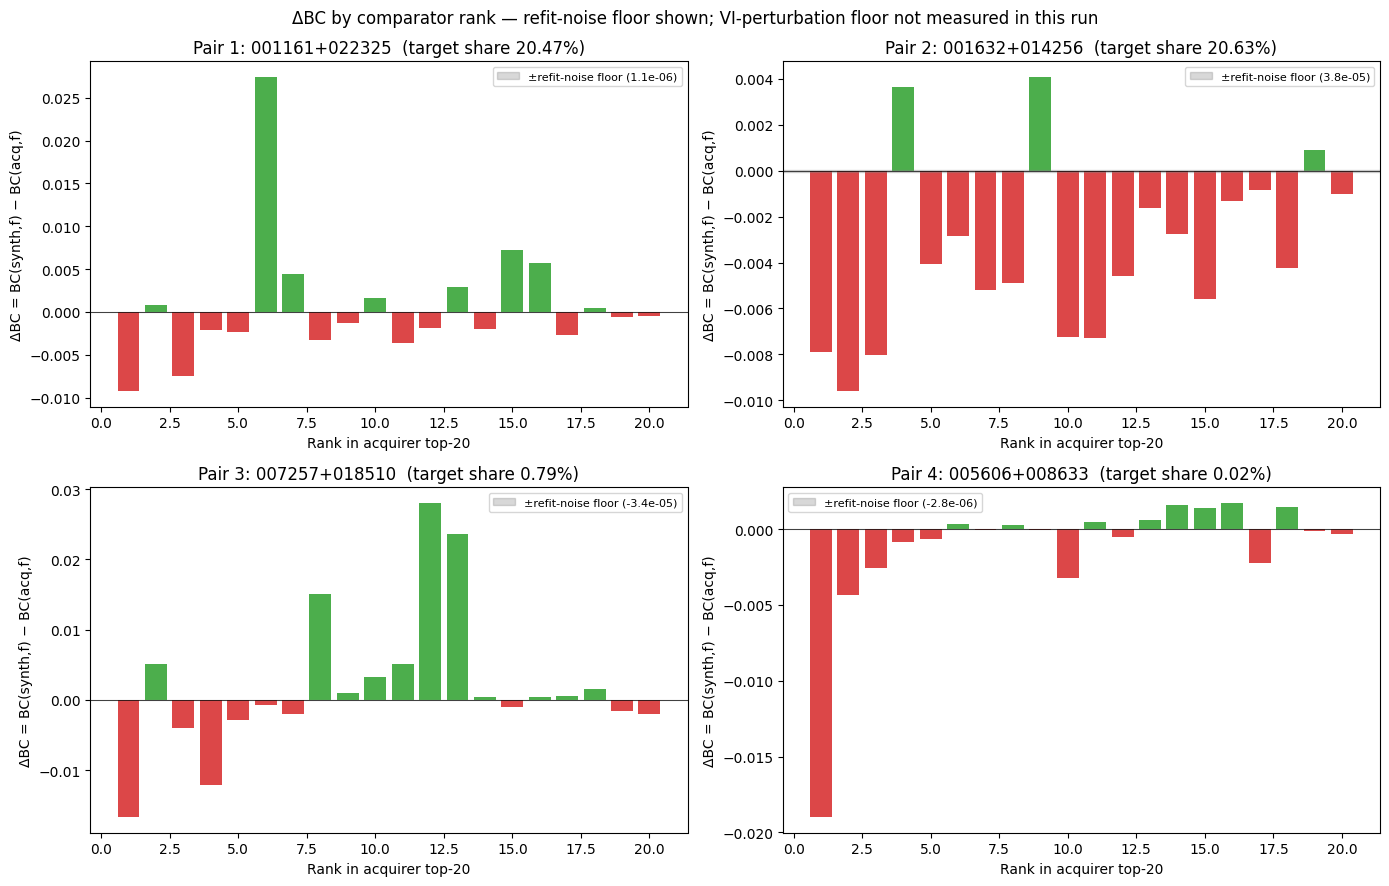

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
for ax, pid in zip(axes.flat, [1, 2, 3, 4]):
    pair_row = PAIRS[PAIRS['pair_id']==pid].iloc[0]
    tbl = COMP[(COMP['pair_id']==pid) & (COMP['role']=='comparator')].copy()
    tbl = tbl.sort_values('rank_in_acquirer_top20')
    colors = ['C2' if x > 0 else 'C3' for x in tbl['delta_bc']]
    ax.bar(tbl['rank_in_acquirer_top20'], tbl['delta_bc'], color=colors, alpha=0.85)
    noise_floor = float(pair_row.max_abs_refit_noise)
    ax.axhspan(-noise_floor, noise_floor, alpha=0.3, color='gray',
               label=f'±refit-noise floor ({noise_floor:.1e})')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Rank in acquirer top-20')
    ax.set_ylabel('ΔBC = BC(synth,f) − BC(acq,f)')
    ax.set_title(f'Pair {pid}: {pair_row.acquirer}+{pair_row.target}  '
                 f'(target share {pair_row.target_patent_share*100:.2f}%)')
    ax.legend(loc='best', fontsize=8)
fig.suptitle('ΔBC by comparator rank — refit-noise floor shown; VI-perturbation floor not measured in this run', fontsize=12)
fig.tight_layout()
plt.savefig('notebooks/05_viz_delta_bc.png', dpi=100, bbox_inches='tight')
plt.show()


## Section 7: Interpretation

We now have ΔBC values we can treat as clean of refit noise but that still mix merger-effect with VI-sensitivity-to-data-perturbation. The honest pair-by-pair reading:

**Pair 1 (001161 + 022325)** — target share 20.5%, pre-merger BC 0.0014. Argmax ΔBC = +0.027 at `PRIV_AILTECHNOLOGIES`, rank 6 in acquirer's top-20. Look at the three BC values: BC(acq, AIL) = 0.0047, BC(tgt, AIL) = 0.0014, BC(synth, AIL) = **0.0321** — the synthetic is ~7× more similar to AILTECHNOLOGIES than either constituent firm alone. This magnitude (target share 20%, ΔBC 0.027) is large enough that VI perturbation from adding 4,466 patents isn't a trivial explanation. **This is the strongest candidate for a real merger-effect signal** in the case study, pending the random-patent-injection calibration.

**Pair 2 (001632 + 014256)** — target share 20.6%, pre-merger BC 0.0108. Argmax |ΔBC| = 0.010 — much smaller than pair 1 despite a comparable target share. Likely explanation: the acquirer and target already overlap technologically (pre-merger BC is 8× higher than pair 1), so the merger doesn't add much new directionality. Nothing in this pair's distribution rises above what VI perturbation could plausibly produce; don't claim a signal here.

**Pair 3 (007257 + 018510)** — target share 0.79%, pre-merger BC 0.0002. Argmax ΔBC = +0.028 at `002403`. This is suspicious because the target is only 99 patents; the magnitude is comparable to pair 1 despite the target being ~45× smaller as a fraction of the portfolio. Most likely interpretation: VI perturbation floor is in the ~0.02 range for this acquirer, and the 99-patent perturbation is enough to hit it. Needs calibration.

**Pair 4 (005606 + 008633)** — target share 0.023%. Argmax |ΔBC| = 0.019 on 9 target patents. Mechanically impossible for the target's *content* to explain this magnitude. Best interpretation: the addition of any 9 patents to this acquirer's 39,719-patent portfolio pushes VI to a different local optimum, producing external-firm BC shifts on the order of 0.02 that are not merger effects. This pair's ΔBC distribution is effectively the **empirical VI-perturbation floor for large acquirers** in the pipeline.

**Overall**: pair 1 is the only pair where the ΔBC magnitude plausibly exceeds what VI perturbation alone could produce, and even there the cleanest interpretation requires the random-patent-injection calibration. The other three pairs contribute mostly to characterizing the VI-perturbation floor itself — which is valuable methodology output for the Step 4 spec, just not itself a merger-effect finding.


## Section 8: Methodology implications for Step 4

Two concrete methodology outputs from this prototype, independent of whether any individual pair's ΔBC represents a merger effect:

1. **VI refit stochasticity does NOT contaminate external-firm BC** under the production-faithful pipeline (same priors, same seed, same data → BC to any third firm is stable to 10⁻⁵). This is a useful invariant for the Step 4 spec: synthetic-portfolio ΔBC methodology does not need a refit-noise baseline.
2. **VI-sensitivity to small data perturbations DOES affect ΔBC to external firms** on the order of ~0.02 for 9-patent perturbations to a 40K-patent acquirer. This *is* a confound for the synthetic-portfolio pipeline: ΔBC of similar magnitude cannot be attributed to merger effect without a perturbation calibration. The Step 4 spec should require the random-patent-injection null distribution as a per-pair input, not just a global hyperparameter.

Both of these shape what ADR-008 will recommend when it's written. They would not have been visible without running this prototype.


## Section 9: Limitations

1. **Prototype, not production.** No ADR, no spec, no unit tests, no Codex review. Production promotion requires ADR-008 for synthetic-portfolio methodology and a significance-testing framework.
2. **Top-20 comparator set** is conditional on the acquirer. Universe-wide BC (all 7,485 firms) removes this restriction and is a prerequisite for any stat-sig claim.
3. **No random-patent-injection calibration.** We cannot yet cleanly separate merger-effect signal from VI-perturbation noise for individual pairs. Section 4 motivates this; Section 10 lists it as the next step.
4. **No significance testing.** All ΔBC values are point estimates.
5. **Single-seed run.** One random_state=42 for synth and acq_refit. Multi-seed would quantify the seed-level uncertainty on top of the data-level uncertainty.
6. **K_max=15 assumption.** Locked per ADR-004; validated by the convergence analysis in Notebook 03 for production BC matrices. Inherited here; not retested for synthetic fits.
7. **Co-assignment assumption.** Zero shared patent_ids across the four pairs (asserted). `run_synthetic_merger` surfaces `n_shared_patents` so swapped pairs with overlap are caught, not silently deduped.


## Section 10: Next steps

Priority-ordered. The first item is the critical one for making sense of pair 1.

1. **Random-patent-injection calibration** (~15 min per pair). For each pair, sample `n_target` patents uniformly from the acquirer's own portfolio, add them to the acquirer, refit, compute ΔBC_null. Repeat 20–50 times to build a per-pair null distribution of |ΔBC|. The actual merger's |ΔBC| is interpretable only relative to this null. This is the single most-important experiment to validate pair 1's signal.
2. **Universe-wide BC per pair** (~20 min per pair). Drop the top-20 restriction. Compute BC(synth, f) for all 7,485 deduplicated firms. Enables global ranking of the merger's pull and is a prerequisite for stat-sig claims.
3. **Permutation / bootstrap significance** (~1 hour per pair). For each comparator, estimate the null distribution of ΔBC by randomly permuting patent-to-firm assignments and refitting. Yields p-values.
4. **Formalize as Step 4** (~1 week). ADR-008 + spec + Codex review + TDD module. Required before this methodology can be cited in the paper as production.
